In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('zomato.csv', encoding= 'latin-1')
print(df.shape)
print(df.columns)

(9551, 21)
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


# finding missing values

In [5]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [6]:
[features for features in df.columns if df[features].isnull().sum()>0]
# this a list comprehension

['Cuisines']

## using heat map to find missing values

<Axes: >

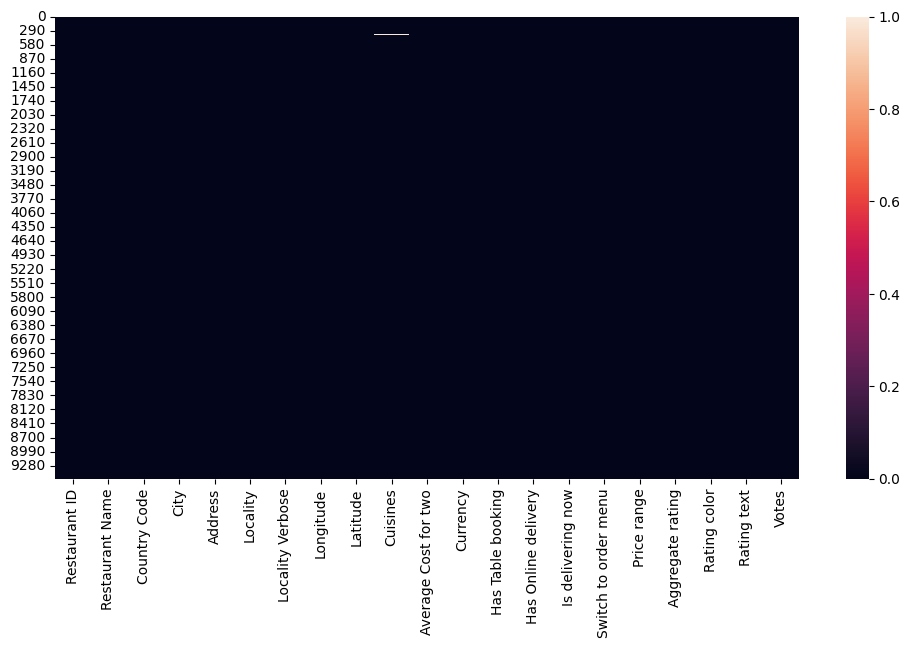

In [70]:
sns.heatmap(df.isnull())

## Got another .xlsx file which has country name for a give country code

In [8]:
df_country = pd.read_excel('Country-Code.xlsx')

In [9]:
df_country.loc[:]

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


## left join them to add the country names to df

In [10]:
final_df = pd.merge(df, df_country, how="left", on="Country Code")

In [50]:
final_df.sample(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
9420,6201309,MRA Bakery Sweets & Restaurant,166,Doha,"Opposite Aster Pharmacy, Al Taei Street, Al Gh...",Al Ghanim,"Al Ghanim, Doha",51.536923,25.280223,"Kerala, Indian, Chinese, Bakery",...,No,No,No,No,3,4.0,Green,Very Good,322,Qatar
6019,18384879,Haji Irshad Biryani Centre,1,New Delhi,"BB-94, Amar Puri, Nabi Karim, Paharganj, New D...",Paharganj,"Paharganj, New Delhi",77.209439,28.624866,Biryani,...,No,No,No,No,1,3.0,Orange,Average,6,India


In [12]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [13]:
final_df.shape

(9551, 22)

In [14]:
final_df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
Country                  object
dtype: object

In [15]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## it is evident that their are no null values

# Finding the ccuntries wise info

In [28]:
final_df['Country'].value_counts()

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
South Africa        60
UAE                 60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Qatar               20
Singapore           20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

In [20]:
country_names = final_df['Country'].value_counts().index
country_names

Index(['India', 'United States', 'United Kingdom', 'Brazil', 'South Africa',
       'UAE', 'New Zealand', 'Turkey', 'Australia', 'Phillipines', 'Indonesia',
       'Qatar', 'Singapore', 'Sri Lanka', 'Canada'],
      dtype='object', name='Country')

In [22]:
country_values = final_df['Country'].value_counts().values
country_values

array([8652,  434,   80,   60,   60,   60,   40,   34,   24,   22,   21,
         20,   20,   20,    4])

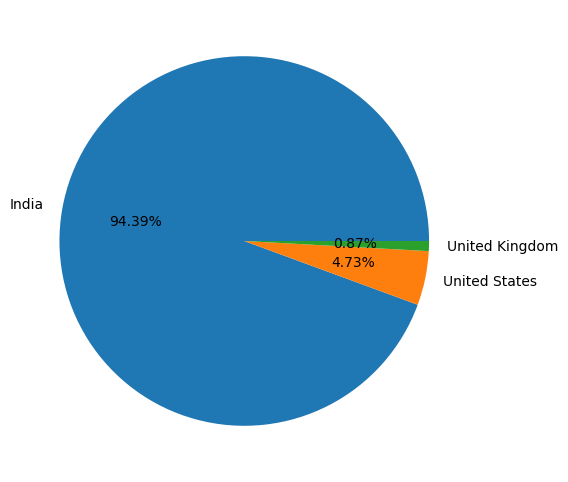

In [69]:
# getting top 3 countries with most orders
plt.pie(x = country_values[:3], labels=  country_names[:3],autopct="%.2f%%")

plt.show()

## Observation:
- Zomato's highest no. of order are from india
while uk and usa contribute to around 5%

# Numerical Variables Analysis

## analysing the ratings

In [38]:
final_df['Aggregate rating'].unique().size

33

In [61]:
# trying to fing the ratings 
# grouping the numerical data related to rating into a view
rating_df = final_df.groupby(['Aggregate rating','Rating color','Rating text']).size()
rating_df = rating_df.reset_index()
# size give give count of the rows accuring
# reset_index() creates a default index of integers. here the df in multiindex. run rating_df.index() to find out
rating_df.rename(columns = {0: 'Ratings count'}, inplace = True) # since the column with count ie size() is named as 0 by default
rating_df

,Aggregate rating,Rating color,Rating text,Ratings count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


## Observation
- when rating is b/w 4.5 to 4.9 -> excellent
- when rating is b/w 4.0 to 4.5 --> very good
- when rating is b/w 3.5 to 3.9 -> good
- when rating is b/w 2.5 to 3.4 -> average
- when rating is b/w 1.8 to 2.4 -> poor
- when ratins is 0.0 -> not rated

In [67]:
import matplotlib

['White' 'Red' 'Orange' 'Yellow' 'Green' 'Dark Green']


<Axes: xlabel='Aggregate rating', ylabel='Ratings count'>

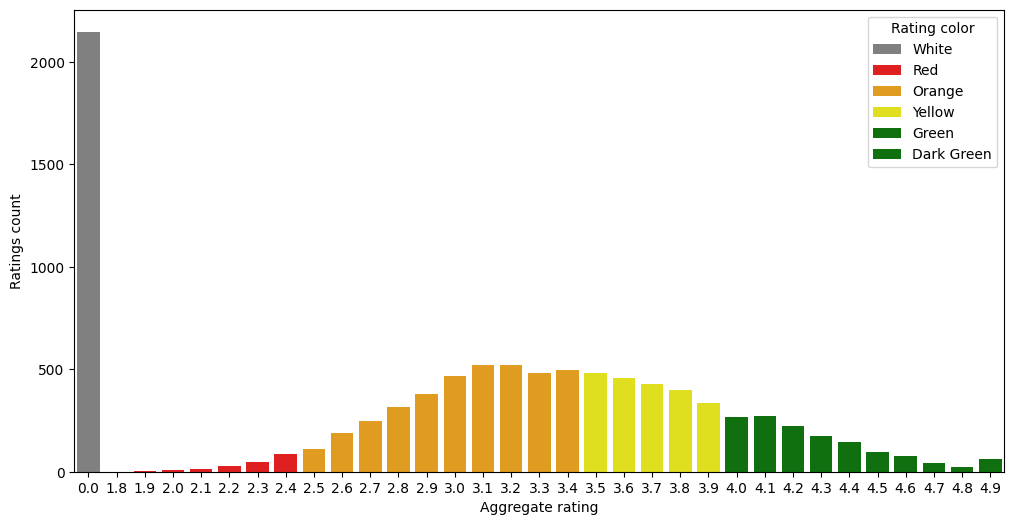

In [80]:
matplotlib.rcParams['figure.figsize'] = (12,6) #  changing figure size parameters. applies for all diagrams in the program

colors = rating_df['Rating color'].unique()
print(colors)

sns.barplot(x="Aggregate rating", y="Ratings count",  hue = 'Rating color',  data= rating_df, palette=['grey','red','orange','yellow','green','green'])

## Obeservation
- most of the restaurants are average rating i.e 2.5 to 3.9
- while bad and excellent rating restaurants are low
- no rating is the highest

<Axes: xlabel='Rating color', ylabel='count'>

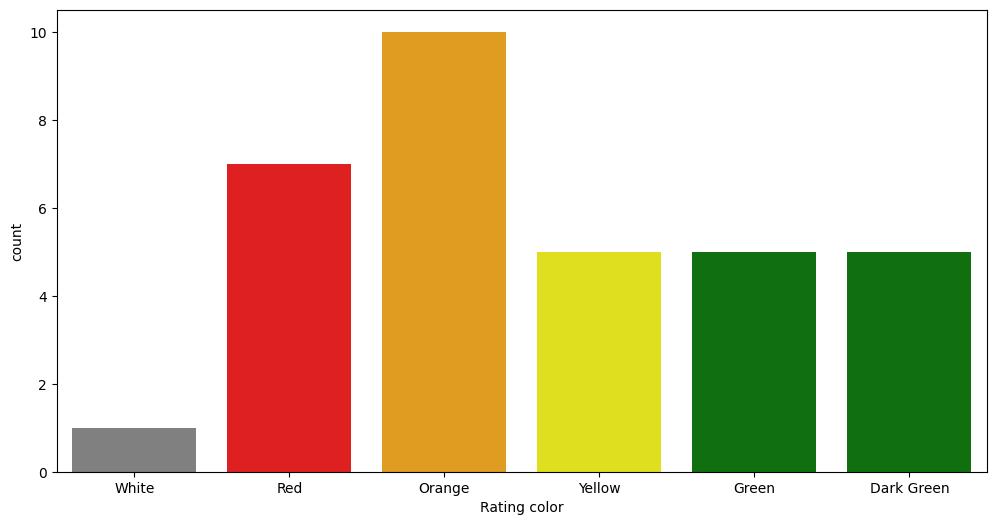

In [82]:
sns.countplot(x = 'Rating color', data = rating_df,hue = 'Rating color',palette=['grey','red','orange','yellow','green','green'])

In [97]:
# finding countries where people give zero rating
final_df.loc[(final_df['Aggregate rating'] == 0.0)].groupby('Country').size().reset_index()

,Country,0
0,Brazil,5
1,India,2139
2,United Kingdom,1
3,United States,3


## Observations
- most 0.0 ratings are from india 

In [105]:
# finding which currency used by which country
final_df.groupby(['Currency','Country']).size().reset_index().drop(columns = 0)

,Currency,Country
0,Botswana Pula(P),Phillipines
1,Brazilian Real(R$),Brazil
2,Dollar($),Australia
3,Dollar($),Canada
4,Dollar($),Singapore
5,Dollar($),United States
6,Emirati Diram(AED),UAE
7,Indian Rupees(Rs.),India
8,Indonesian Rupiah(IDR),Indonesia
9,NewZealand($),New Zealand


In [122]:
# which countries have online deliveries
final_df[final_df["Has Online delivery"] == 'Yes']["Country"].value_counts()


Country
India    2423
UAE        28
Name: count, dtype: int64

## OBservation:
- online deliveries are available in india and uae only

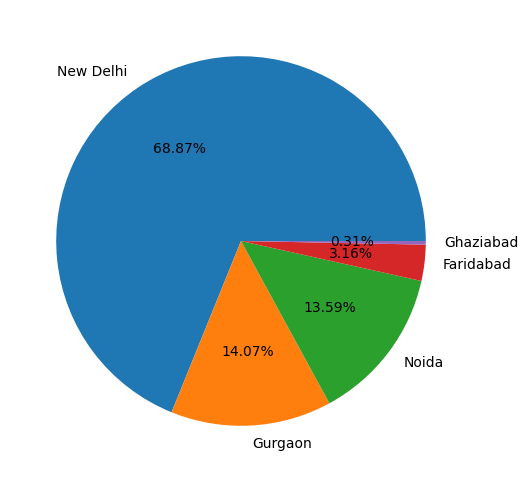

In [145]:
# create a pie chart for cities distribution
city_orders_df = final_df["City"].value_counts().reset_index()
plt.pie(city_orders_df['count'][:5], labels = city_orders_df["City"][:5], autopct = "%.2f%%")
plt.show()

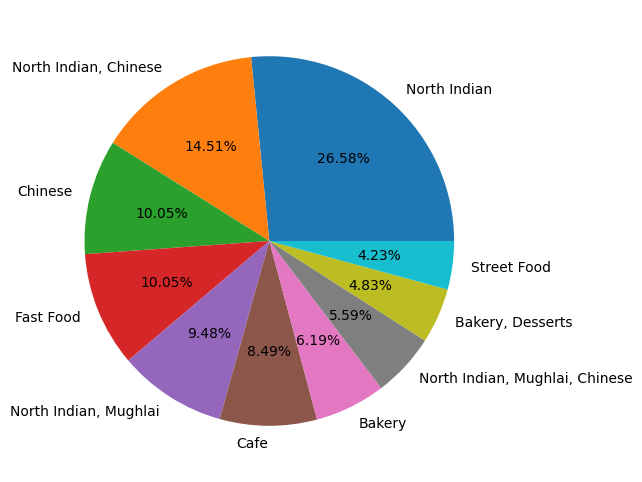

In [149]:
## find the top 10 cuisines
cuisines_df = final_df["Cuisines"].value_counts().reset_index()
plt.pie(cuisines_df['count'][:10], labels = cuisines_df["Cuisines"][:10], autopct = "%.2f%%")
plt.show()
# cuisines_df